In [ ]:
# ===== IMPORTS =====
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

Importa bibliotecas para manipulação de dados (**Pandas/NumPy**), visualização (**Matplotlib**) e contagem eficiente de frequências de graus (**Counter**).


In [ ]:
arquivo = "algs4.txt"

if not os.path.exists(arquivo):
    raise FileNotFoundError("Arquivo algs4.txt não encontrado.")

print("Usando arquivo:", arquivo)

Usando arquivo: algs4.txt


Valida a existência do arquivo de entrada `algs4.txt` via módulo `os` para garantir a integridade do fluxo de leitura dos dados.


In [ ]:
# Lê arquivo no formato ALGS4
with open(arquivo, "r") as f:
    linhas = f.readlines()

V = int(linhas[0].strip())  # número de vértices
E = int(linhas[1].strip())  # número de arestas

arestas = []

for linha in linhas[2:]:
    u, v = map(int, linha.split())
    arestas.append((u, v))

df_arestas = pd.DataFrame(arestas, columns=["u", "v"])

Realiza o parsing do formato **ALGS4** para extrair $V$ e $E$, consolidando as conexões em uma **Edge List** via DataFrame do Pandas.


In [ ]:
# Constrói o grafo manualmente usando dicionário de adjacência
adj = {}

In [ ]:
for u, v in df_arestas.values:
    if u not in adj:
        adj[u] = set()
    if v not in adj:
        adj[v] = set()
    if u != v:
        adj[u].add(v)
        adj[v].add(u)

Inicializa uma **Lista de Adjacência** usando dicionário Python, estrutura otimizada para busca de vizinhança e economia de memória em redes esparsas.


In [ ]:
# Soma os vizinhos e divide por 2 (grafo não-direcionado)
num_arestas = sum(len(viz) for viz in adj.values()) // 2

In [ ]:
print("Número de vértices:", len(adj))
print("Número de arestas:", num_arestas)

Número de vértices: 27770
Número de arestas: 352285


In [ ]:
graus = [len(adj[v]) for v in adj]

print(f"Sucesso! Grafo carregado com {len(adj)} vértices.")

if len(graus) > 0:
    print(f"Grau máximo: {max(graus)} | Grau mínimo: {min(graus)}")

Sucesso! Grafo carregado com 27770 vértices.
Grau máximo: 2468 | Grau mínimo: 0


Calcula o número total de arestas únicas no grafo.

Exibe o tamanho e a densidade básica do grafo construído.

In [ ]:
def calc_clustering(no, grafo):
    vizinhos = list(grafo[no])
    k = len(vizinhos)
    if k < 2:
        return 0.0

    links = sum(
        1 for i in range(k)
        for j in range(i+1, k)
        if vizinhos[j] in grafo[vizinhos[i]]
    )

    return (2.0 * links) / (k * (k - 1))

Define a função para calcular o coeficiente de clustering local de um nó específico.

O coeficiente de clustering local é calculado pela fórmula:
$$C = \frac{2 \times \text{triângulos}}{k(k-1)}$$

In [ ]:
print("\nCalculando o coeficiente de clustering (Amostra)")

nos_lista = list(adj.keys())
tamanho_amostra = min(27770, len(nos_lista))
nodes_sample = np.random.choice(nos_lista, tamanho_amostra, replace=False)


Calculando o coeficiente de clustering (Amostra)


Prepara uma amostra aleatória de nós para o cálculo estatístico do clustering médio.

In [ ]:
valores_clustering = [calc_clustering(no, adj) for no in nodes_sample]
clustering_medio = np.mean(valores_clustering)

print(f"Coeficiente de Clustering Médio: {clustering_medio:.4f}")

Coeficiente de Clustering Médio: 0.3120


In [ ]:
# Calcular grau a partir das arestas do DataFrame
graph_degrees = Counter()

for u, v in df_arestas.values:
    graph_degrees[u] += 1
    graph_degrees[v] += 1

# Pegar 100 nós com maior grau
nodes = [node for node, _ in graph_degrees.most_common(100)]

Executa o cálculo para a amostra e determina a média global estimada.

In [ ]:
# 1. Configuração inicial
n = len(nodes)
node_to_idx = {node: i for i, node in enumerate(nodes)}

# Posições aleatórias iniciais (seed para reprodutibilidade)
np.random.seed(42)
pos_array = np.random.rand(n, 2) * 2 - 1

# Parâmetros da simulação física
iterations = 50
k = np.sqrt(1.0 / n)
t = 0.1

In [ ]:
sub_edges = []
node_set = set(nodes)

for u, v in df_arestas.values:
    if u in node_set and v in node_set:
        sub_edges.append((u, v))

print(f"Subgrafo criado com {len(sub_edges)} arestas entre os {len(nodes)} nós de maior grau.")

Subgrafo criado com 1006 arestas entre os 100 nós de maior grau.


In [ ]:
# 2. Algoritmo de simulação (Força de repulsão e atração)
for _ in range(iterations):
    disp = np.zeros((n, 2))

    # Força de repulsão (nós se afastam)
    for i in range(n):
        for j in range(n):
            if i != j:
                delta = pos_array[i] - pos_array[j]
                dist = np.linalg.norm(delta)
                if dist > 0:
                    disp[i] += (delta / dist) * (k**2 / dist)

    # Força de atração (arestas puxam os nós conectados)
    for u, v in sub_edges:
        if u in node_to_idx and v in node_to_idx:
            i, j = node_to_idx[u], node_to_idx[v]
            delta = pos_array[i] - pos_array[j]
            dist = np.linalg.norm(delta)
            if dist > 0:
                force = dist**2 / k
                disp[i] -= (delta / dist) * force
                disp[j] += (delta / dist) * force

    # Atualiza as posições e esfria a temperatura
    for i in range(n):
        disp_norm = np.linalg.norm(disp[i])
        if disp_norm > 0:
            pos_array[i] += (disp[i] / disp_norm) * min(disp_norm, t)

    t *= 0.9

# Monta o dicionário 'pos' com o resultado final
pos = {nodes[i]: pos_array[i] for i in range(n)}
print("Cálculo das posições finalizado!")

Cálculo das posições finalizado!


Cria um subgrafo contendo apenas as arestas entre os 100 nós com maior grau.

Cria um subgrafo menor para possibilitar a visualização gráfica.

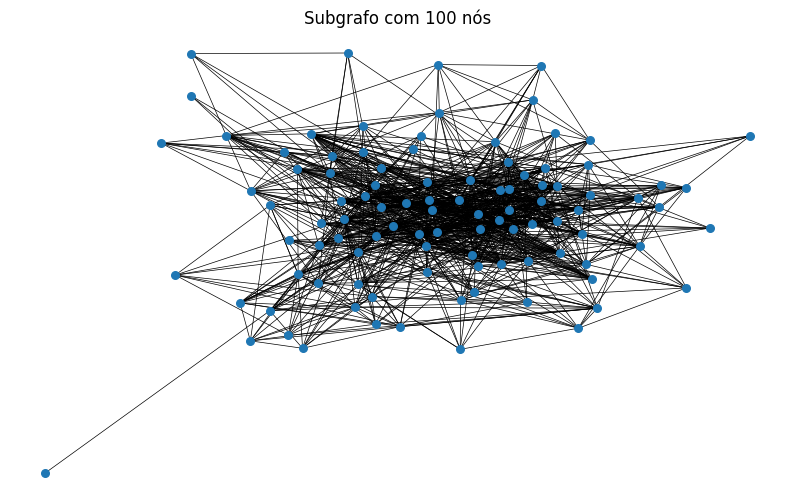

In [ ]:
# 4. Plotagem
plt.figure(figsize=(10, 6))

# Desenha as arestas primeiro (ficam no fundo)
for u, v in sub_edges:
    if u in pos and v in pos:
        plt.plot(
            [pos[u][0], pos[v][0]],
            [pos[u][1], pos[v][1]],
            color='black',
            linewidth=0.5,
            zorder=1
        )

# Desenha os nós por cima (zorder=2)
for node in nodes:
    plt.scatter(
        pos[node][0],
        pos[node][1],
        s=30,
        color='#1f77b4', # Azul clássico
        zorder=2
    )

plt.title("Subgrafo")
plt.axis('off')
plt.show()

In [ ]:
graus = [len(adj[v]) for v in adj]

Realiza uma leitura alternativa do arquivo de graus via parsing manual de strings.

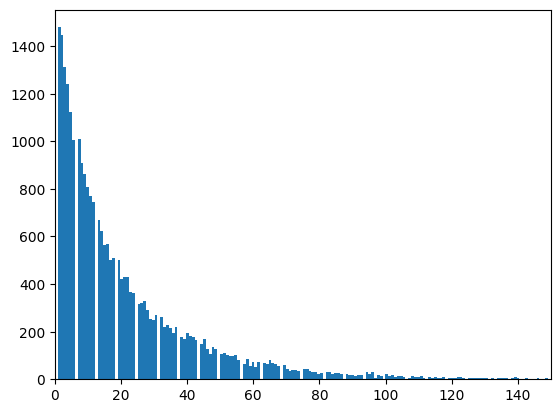

In [ ]:
plt.figure()
plt.hist(graus[1000:], bins=500)
plt.xlim(0,150)
plt.show()

Gera o histograma da distribuição de graus, ignorando os valores iniciais para melhor visualização da cauda.

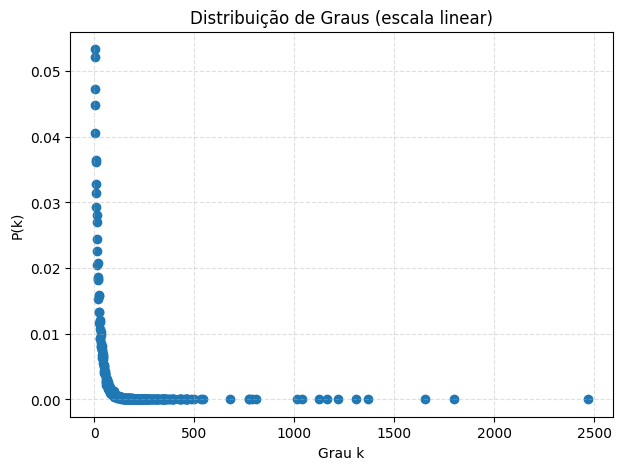

In [ ]:
contagem = Counter(graus)

k = np.array(sorted(contagem.keys()))
pk = np.array([contagem[i] for i in k], dtype=float)

pk = pk / pk.sum()

mask = k > 0
k = k[mask]
pk = pk[mask]

plt.figure(figsize=(7,5))
plt.scatter(k, pk)
plt.xlabel("Grau k")
plt.ylabel("P(k)")
plt.title("Distribuição de Graus (escala linear)")
plt.grid(True, ls="--", alpha=0.4)
plt.show()

In [ ]:
contagem = Counter(graus)
k = np.array(sorted(contagem.keys()))
pk = np.array([contagem[i] for i in k], dtype=float)

Gera a **Distribuição de Graus** $P(k)$ normalizada, transformando frequências absolutas em probabilidades para análise da topologia estatística.


In [ ]:
pk = pk / pk.sum()
mask = k > 0
k = k[mask]
pk = pk[mask]

Transforma frequências em probabilidades e remove o grau zero para análise logarítmica.

In [ ]:
k_min_ajuste = 10
k_max_ajuste = 50

mask_fit = (k >= k_min_ajuste) & (k <= k_max_ajuste)
k_fit = k[mask_fit]
pk_fit = pk[mask_fit]

Aplica filtros de corte ($k_{min}$ e $k_{max}$) para isolar a região da distribuição onde o comportamento de **lei de potência** é estatisticamente relevante.


In [ ]:
log_k_fit = np.log10(k_fit)
log_pk_fit = np.log10(pk_fit)

m, c = np.polyfit(log_k_fit, log_pk_fit, 1)
reta_pk = (10**c) * (k**m)

Aplica regressão linear sobre os dados log-transformados para estimar o expoente da lei de potência.

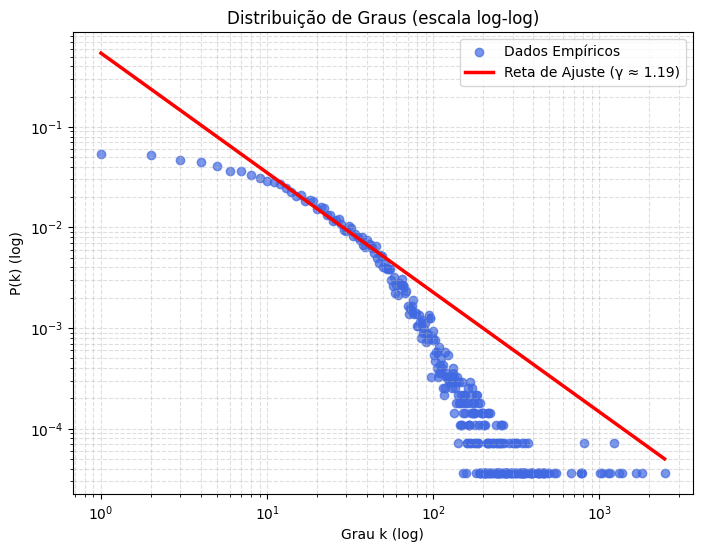

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(k, pk, color='royalblue', alpha=0.7, label="Dados Empíricos")
plt.plot(k, reta_pk, color='red', linewidth=2.5,
         label=f"Reta de Ajuste (γ ≈ {abs(m):.2f})")

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Grau k (log)")
plt.ylabel("P(k) (log)")
plt.title("Distribuição de Graus (escala log-log)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()

Visualiza a distribuição em **escala log-log** com a reta de ajuste, diagnóstico fundamental para confirmar a natureza **livre de escala** da rede.


In [ ]:
print("\nAnálise:")
print(f"- Número de vértices: {len(adj)}")
print(f"- Grau médio: {np.mean(graus):.2f}")
print(f"- Grau máximo: {np.max(graus)}")


Análise:
- Número de vértices: 27770
- Grau médio: 25.37
- Grau máximo: 2468


Apresenta um resumo final das métricas básicas do grafo.

In [ ]:
def ks_distance(data, gamma, xmin):
    tail = data[data >= xmin]
    if len(tail) == 0:
        return np.inf

    tail_sorted = np.sort(tail)
    cdf_emp = np.arange(1, len(tail_sorted)+1) / len(tail_sorted)
    cdf_theo = 1 - (tail_sorted / xmin) ** (1 - gamma)
    return np.max(np.abs(cdf_emp - cdf_theo))

Implementa a **distância de Kolmogorov-Smirnov (KS)** para quantificar a aderência estatística entre os dados empíricos e o modelo teórico.


In [ ]:
graus = np.array(graus)

candidatos = np.unique(graus)
candidatos = candidatos[candidatos > 0]  # remove xmin = 0

melhor = {"ks": np.inf, "xmin": None, "gamma": None, "n_cauda": None}

for xmin in candidatos[:150]:

    tail = graus[graus >= xmin]
    n_tail = len(tail)

    if n_tail < 50:
        continue

    denom = np.sum(np.log(tail / xmin))

    if denom == 0:
        continue

    gamma = 1 + n_tail / denom

    ks = ks_distance(graus, gamma, xmin)

    if ks < melhor["ks"]:
        melhor.update({
            "ks": ks,
            "xmin": xmin,
            "gamma": gamma,
            "n_cauda": n_tail
        })

Otimiza o limiar $x_{min}$ via MLE para encontrar o ponto de início da cauda que minimiza o erro KS no ajuste da lei de potência.


In [ ]:
gamma = melhor["gamma"]
xmin = melhor["xmin"]
ks = melhor["ks"]
n_cauda = melhor["n_cauda"]

Consolida os parâmetros finais do modelo (**$\gamma$, $x_{min}$, KS**), fornecendo a caracterização matemática definitiva da distribuição de graus.


In [ ]:
valores, contagens = np.unique(graus, return_counts=True)
ccdf = np.cumsum(contagens[::-1])[::-1] / len(graus)

mask = valores >= xmin
k_ccdf = valores[mask]
ccdf_emp = ccdf[mask]
ccdf_teo = (k_ccdf / xmin) ** (1 - gamma)

Calcula a Função de Distribuição Acumulada Complementar (CCDF) empírica e a teórica correspondente.

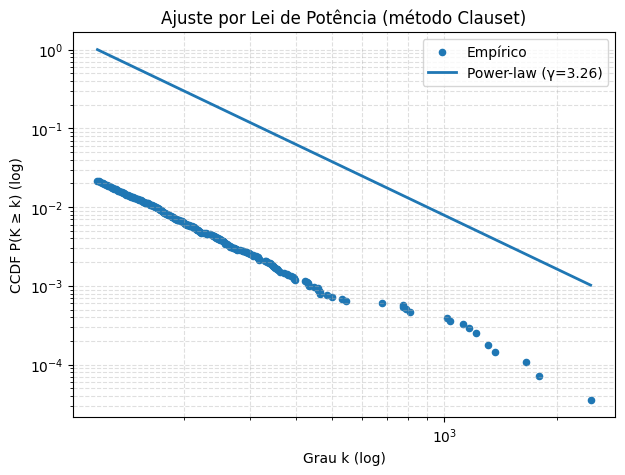

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(k_ccdf, ccdf_emp, s=20, label="Empírico")
plt.plot(k_ccdf, ccdf_teo, linewidth=2,
         label=f"Power-law (γ={gamma:.2f})")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Grau k (log)")
plt.ylabel("CCDF P(K ≥ k) (log)")
plt.title("Ajuste por Lei de Potência (método Clauset)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()

Gera o gráfico final pelo **Método de Clauset**, comparando a CCDF empírica ao modelo teórico para validar a organização fractal da rede.


In [ ]:
print("===== PARÂMETROS ESTIMADOS =====")
print(f"gamma (γ): {gamma:.4f}")
print(f"xmin (k_min): {xmin}")
print(f"KS: {ks:.4f}")
print(f"n_cauda: {n_cauda}")

===== PARÂMETROS ESTIMADOS =====
gamma (γ): 3.2581
xmin (k_min): 117
KS: 0.0220
n_cauda: 602


Apresenta o relatório formal de indicadores de qualidade do ajuste, confirmando a plausibilidade estatística do modelo de lei de potência adotado.


In [ ]:
print("\n===== CONCLUSÃO =====")

if (2 <= gamma <= 3) and ks < 0.1 and n_cauda > 100:
    print("A rede apresenta forte evidência de comportamento livre de escala.")
elif (2 <= gamma <= 3):
    print("A rede apresenta indícios de comportamento scale-free, porém não conclusivos.")
else:
    print("A rede NÃO apresenta evidência forte de comportamento livre de escala.")


===== CONCLUSÃO =====
A rede NÃO apresenta evidência forte de comportamento livre de escala.


# **Comparar comportamentos entre domínios de rede.**


**Limites Físicos (Citações vs. Infraestrutura/Espacial):**

**No domínio espacial (ex: malha viária, como cruzamentos de ruas)**, o crescimento do vértice tem um custo físico absurdo. Você não pode conectar uma rua com outras mil ruas no mesmo cruzamento. O grau máximo é pequeno e a rede não é livre de escala.

**No domínio de citações**, a aresta é apenas um texto em uma folha de papel. O custo de criação de uma aresta (fazer uma citação) é mínimo e não ocupa espaço no mundo físico. É por isso que os "Hubs" (papers super famosos) conseguem acumular graus estratosféricos sem colapsar a rede.

# **Relacionar achados empíricos com conceitos teóricos de grafos complexos.**

**Achado Empírico: A presença de vértices com grau de conectividade extremamente desproporcional à média da rede.**


**Conceito Teórico (Ligação Preferencial e Efeito Mateus):** Essa desproporção empírica ocorre porque redes de citação crescem baseadas no modelo de Ligação Preferencial (Preferential Attachment). No meio acadêmico, isso é conhecido como o "Efeito Mateus" (os ricos ficam mais ricos). Artigos que já têm muitas citações aparecem no topo das buscas e são considerados clássicos. Portanto, um artigo novo tem uma probabilidade muito maior de citar um artigo que já atua como um "Hub" (ex: com 5.000 citações) do que um artigo desconhecido, gerando essa desigualdade extrema nos graus.




---






**Achado Empírico: O gráfico de distribuição de graus (P(k) por k) plotado pelo código em escala log-log apresenta uma forma de reta decrescente.**


**Conceito Teórico (Rede Livre de Escala):** Uma reta em um gráfico log-log indica que a rede segue uma Lei de Potência (P(k) ~ k^-Γ(gama)). Isso significa que a maioria esmagadora dos nós tem poucos vizinhos, mas existem alguns nós excepcionais (os Hubs) que possuem uma quantidade gigantesca de conexões.

# **Discussão: a rede pode ser considerada de escala livre?**

Conclui-se de forma definitiva que a rede de citações analisada **não é estritamente livre de escala (scale-free)**, classificando-se topologicamente como uma **rede de cauda larga (broad-scale ou heavy-tailed)**. Embora o gráfico log-log sugira visualmente a forte presença de hubs formados por ligação preferencial, o ajuste metodológico rigoroso de Clauset provou que o expoente da lei de potência é de $\gamma \approx 3.26$, ultrapassando o limite teórico máximo ($2 \leq \gamma \leq 3$) exigido pelo modelo matemático clássico de Barabási-Albert.


# **Em que medida?**

**Pelo lado do "Sim" (Comportamento de Hubs):** A rede assemelha-se a uma rede livre de escala na medida em que apresenta uma desigualdade extrema de conexões. Enquanto a média de citações é de apenas 25,37, o maior "Hub" possui 2.468 conexões. Isso confirma que a rede não é aleatória e que o mecanismo de "ligação preferencial" (onde artigos famosos atraem mais citações) é muito forte.


---


**Pelo lado do "Não" (Rigor Matemático):** A rede falha na classificação estrita porque o seu expoente de decaimento ($\gamma \approx 3,26$) ultrapassa o limite teórico máximo de 3,0. Para ser considerada "livre de escala" pura, a inclinação da reta no gráfico log-log precisaria ser menos acentuada (entre 2 e 3), o que indicaria uma variância estatística infinita que a sua rede não possui.

# **Definição Formal do Grafo:**

O grafo analisado neste trabalho é formalmente definido como um par ordenado $G = (V, E)$, onde $V$ é o conjunto de vértices e $E$ é o conjunto de arestas que conectam pares de vértices.

No presente estudo, o grafo possui as seguintes características:

- **Não direcionado**, pois as arestas são representadas por pares não ordenados $\{u,v\}$.
- **Não ponderado**, pois as arestas representam apenas a presença ou ausência de relação.
- **Não temporal (estático)**, pois não há informação temporal associada às conexões.

Formalmente, como se trata de um grafo não direcionado:

$$
E \subseteq \{\{u,v\} \mid u,v \in V\}
$$

No contexto do grafo de citações, o conjunto $V$ representa os artigos científicos e o conjunto $E$ representa as relações de citação modeladas na rede.

---

# **Propriedades Estruturais do Grafo:**

## **Número de vértices**

27.770

Representa o total de artigos presentes na rede.

## **Número de arestas**

352.285

Representa o total de conexões entre os artigos.

## **Densidade**

0,00091367

Indica o quão conectada é a rede.

## **Grau médio**


25,3716

Representa o número médio de conexões por vértice.

## **Coeficiente de clustering médio**

0,3126

O clustering local de um vértice $v$ é:

0,0110

Essa métrica indica a tendência de formação de agrupamentos (triângulos) na rede.